Import statements

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dataset

In [148]:
dataset = pd.read_csv('./salary.csv')

dataset['Date-of-birth'] = pd.to_datetime(dataset['Date-of-birth'])
dataset['days_since'] = (
    dataset['Date-of-birth'] - dataset['Date-of-birth'].min()
).dt.days
dataset = dataset.drop('Date-of-birth',axis=1)
print(dataset)
X = dataset.iloc[:,:-2].values
Y = dataset.iloc[:, -2].values
print(X)
print(Y)

    Yearsofexperience      Salary  days_since
0                   7    68205.10       10448
1                   6    53146.83       10697
2                  35  1124097.47         555
3                  28  4945339.87        5059
4                  18   166797.52        6811
..                ...         ...         ...
95                  0    40000.00       13586
96                 34   766430.10        3268
97                 20  1533504.00        8349
98                 32   844551.07        4098
99                  4    51243.50       11290

[100 rows x 3 columns]
[[ 7]
 [ 6]
 [35]
 [28]
 [18]
 [20]
 [24]
 [ 5]
 [ 9]
 [23]
 [35]
 [31]
 [30]
 [14]
 [ 6]
 [30]
 [29]
 [35]
 [32]
 [12]
 [ 9]
 [31]
 [31]
 [35]
 [29]
 [28]
 [17]
 [ 9]
 [28]
 [12]
 [17]
 [ 0]
 [ 8]
 [32]
 [19]
 [12]
 [ 4]
 [ 1]
 [20]
 [10]
 [21]
 [25]
 [34]
 [ 1]
 [ 8]
 [17]
 [19]
 [31]
 [33]
 [17]
 [ 5]
 [11]
 [35]
 [ 7]
 [13]
 [35]
 [27]
 [11]
 [17]
 [10]
 [16]
 [15]
 [35]
 [29]
 [20]
 [ 7]
 [16]
 [27]
 [ 7]
 [ 1]
 [ 3

splitting dataset into Training set and Test set

In [149]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)

Training the Simple Linear Regression model on the Training set

In [150]:
from sklearn.linear_model import LinearRegression 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#the handle unknown in the OneHotEncoder handle the new categories coming 
#ct = ColumnTransformer([("encoder",OneHotEncoder(handle_unknown='ignore'),[0])],remainder='passthrough')
#fit the training data
#x_train = ct.fit_transform(x_train) 

#ONLY transform test data
#x_test = ct.transform(x_test)

regressor = LinearRegression() 
regressor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Predicting the Test set results

In [151]:
#print(x_test)
y_pred = regressor.predict(x_test)

Visualising the Training set results

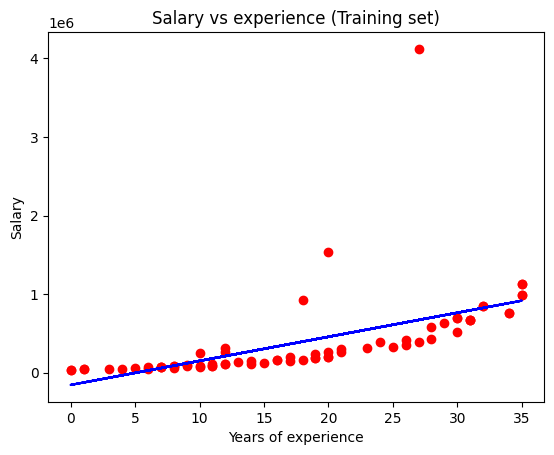

In [152]:
plt.scatter(x_train,y_train,color='red')
plt.plot(x_train, regressor.predict(x_train),color='blue')
plt.title('Salary vs experience (Training set)')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.show()

Visualising the Test set results

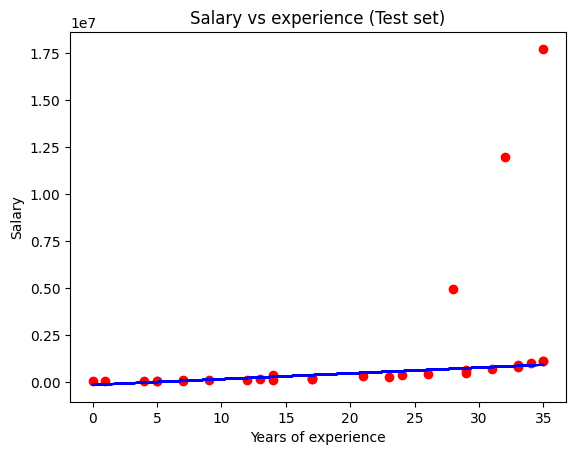

In [153]:
plt.scatter(x_test,y_test,color='red')
plt.plot(x_train, regressor.predict(x_train),color='blue')
plt.title('Salary vs experience (Test set)')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.show()